**STEP 01 IMPORT LIBRARIES**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

import networkx as nx

**STEP 02 LOAD DATASET**

In [ ]:
df = pd.read_csv("engineered_accessibility_dataset.csv")

**STEP 03 SELECT FEATURES**

In [ ]:
X = df.drop(columns=[
    "Accessibility_Score",
    "Accessibility_Category",
    "Improvement_Priority",
    "Location_ID",
    "Location_Name"
], errors="ignore")

**STEP 04 SCALE FEATURES**

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**STEP 05 PCA (2 COMPONENTS)**

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.18858693 0.05171474]


**STEP 06 PCA VISUALIZATION**

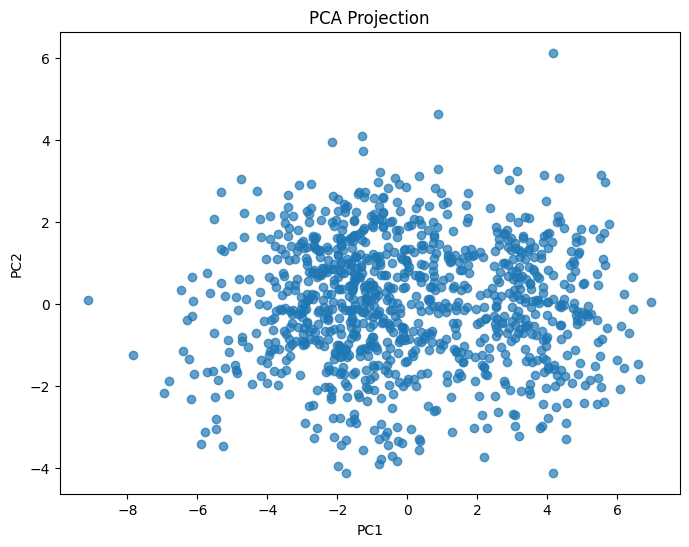

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# **DBSCAN**

**STEP 07**

In [ ]:
dbscan = DBSCAN(
    eps=2,
    min_samples=8
)

db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels


# for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
#     db = DBSCAN(eps=eps, min_samples=5)
#     labels = db.fit_predict(X_scaled)

#     print(
#         "eps =", eps,
#         "Clusters =", len(set(labels)) - (1 if -1 in labels else 0),
#         "Noise =", list(labels).count(-1)
#     )

**STEP 08**

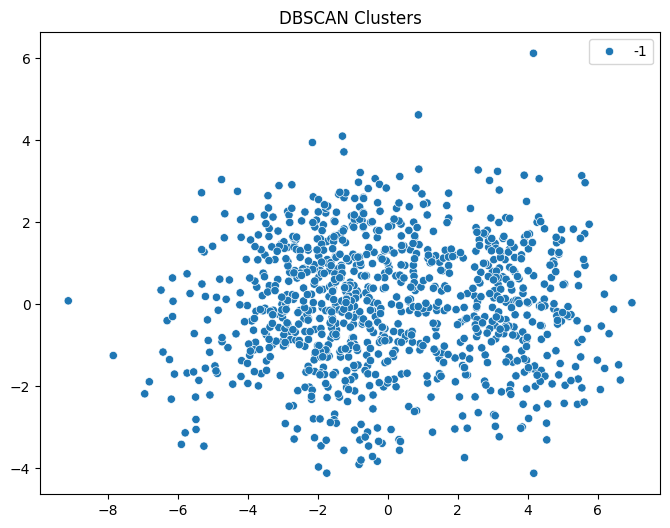

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=db_labels,
    palette="tab10"
)

plt.title("DBSCAN Clusters")

plt.show()

**STEP 09**

In [ ]:
print(df["DBSCAN_Cluster"].value_counts())

DBSCAN_Cluster
-1    1000
Name: count, dtype: int64


# **EXPECTATION MAXIMIZATION (GAUSSIAN MIXTURE)**

**STEP 10**

In [ ]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)
df["GMM_Cluster"] = gmm_labels

**STEP 11**

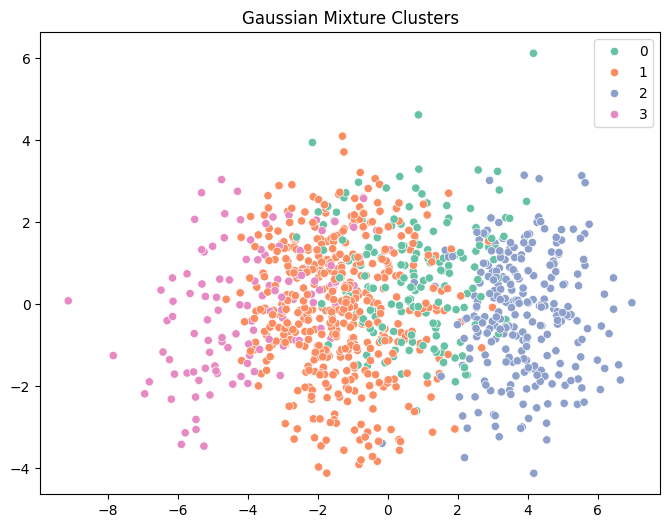

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=gmm_labels,
    palette="Set2"
)
plt.title("Gaussian Mixture Clusters")
plt.show()

**STEP 12**

In [ ]:
print(df["GMM_Cluster"].value_counts())

GMM_Cluster
1    468
2    251
0    164
3    117
Name: count, dtype: int64


# **MINIMUM SPANNING TREE (MST)**

**STEP 13 DISTANCE MATRIX**

In [ ]:
distance_matrix = squareform(
    pdist(X_scaled)
)

**STEP 14 CREATE MST**

In [ ]:
mst = minimum_spanning_tree(
    distance_matrix
)

**STEP 15 CONVERT TO GRAPH**

In [ ]:
graph = nx.from_scipy_sparse_array(mst)

**STEP 16 DRAW GRAPH**

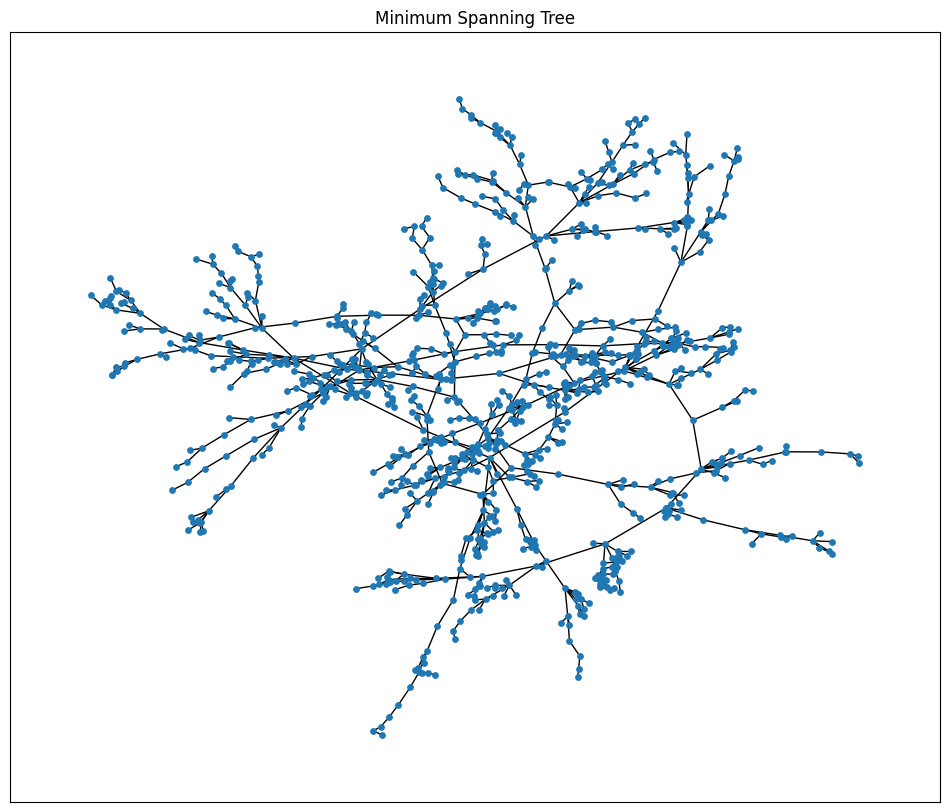

In [ ]:
plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    graph,
    seed=42
)
nx.draw_networkx(
    graph,
    pos,
    node_size=15,
    with_labels=False
)
plt.title("Minimum Spanning Tree")
plt.show()

**COMPARE CLUSTERING RESULTS**

In [ ]:
print("DBSCAN")
print(df["DBSCAN_Cluster"].value_counts())
print()
print("Gaussian Mixture")
print(df["GMM_Cluster"].value_counts())

DBSCAN
DBSCAN_Cluster
-1    1000
Name: count, dtype: int64

Gaussian Mixture
GMM_Cluster
1    468
2    251
0    164
3    117
Name: count, dtype: int64


**CLUSTER SUMMARY**

In [ ]:
cluster_summary = df.groupby(
    "GMM_Cluster"
).mean(numeric_only=True)

cluster_summary

,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,Number_of_Floors,Ramp_Available,...,Emergency_Exit_Accessibility,Accessibility_Score,Infrastructure_Score,Accessibility_Support_Score,Safety_Index,Facility_Score,Crowd_Risk,Complaint_Rate,Accessibility_Efficiency,DBSCAN_Cluster
GMM_Cluster,,,,,,,,,,,,,,,,,,,,,
0,3.591463,12.573171,7.603659,20.275350,77.432789,0.274390,34.762195,15.018293,3.426829,0.658537,...,1.371951,71.129878,3.012195,1.140244,2.585366,1.207317,21.963415,0.001900,5.184737,-1.0
1,4.183761,12.591880,7.809829,19.643416,78.081336,1.000000,37.117521,14.527778,1.638889,0.420940,...,0.912393,49.614744,1.861111,0.805556,2.651709,1.348291,17.728632,0.002476,3.387642,-1.0
2,2.605578,12.565737,7.836653,20.015620,77.804860,0.358566,14.322709,8.940239,4.517928,0.812749,...,1.605578,87.984861,3.872510,1.565737,2.717131,1.302789,22.565737,0.000229,4.959317,-1.0
3,7.042735,12.256410,7.649573,21.752189,77.834100,0.837607,93.341880,24.410256,1.000000,0.247863,...,0.632479,34.266667,1.393162,0.452991,2.649573,1.179487,13.307692,0.007933,3.017286,-1.0


**SAVE DATASET**

In [ ]:
df.to_csv(
    "clustered_accessibility_dataset.csv",
    index=False
)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    gmm_labels
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.048
